#Universidad del Gran Rosario - UGR
#Ingeniería del Software
##Trabajo Práctico
###Introducción a las metodologías y procesos de Ciencia de Datos
####Docentes: Ing. Ignacio Sanseovich - Lic. Briant Gauna

####Estudiantes:
* Ocanto Victor
* Chamo Ruben
* Negrette Martina
* Rikal Federico
* Aquino Alejandro
* Jazmatie Alejandro
* Torres Santiago



In [ ]:
# @title AI prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)

GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…

###Estudio de Caso
Este trabajo se basa en la aplicación de una metodología de Minería de Datos y su implementación en una solución de software.

Lo que se espera es que el grupo desarrolle:
* Una metodología clara de cómo se procesarán los datos y su resultado e interpretación.
* Las vistas y montaje de la solución de software que dará vida a esta metodología para conectar el proceso de datos con el usuario final.

Elegiremos trabajar con la Metodología CRISP-DM (Cross-Industry Standard Process for Data Mining).

La entrega constará de:
* Esta notebook completa
* El link desde donde se puede acceder al producto de software implementado

##Fases del Trabajo:

##Fase #1: Comprensión del Negocio / Business Understanding:
Esta fase inicial se centra en comprender los objetivos y requisitos del proyecto desde una perspectiva de negocio, para luego convertir este conocimiento en una definición del problema de minería de datos y un plan preliminar diseñado para lograr los objetivos.

* Elegí un problema de negocio que puedas resolver con datos. Describilo brevemente.
* ¿Cuál es el objetivo principal del análisis? Elaborá un objetivo general y algunos específicos. Te ayudarán a clasificar las tareas más adelante.
* Enumerá los distintos Stakeholders del negocio donde está inmerso el problema.
* ¿Qué impacto tendrá la solución en el negocio o en la toma de decisiones? Justificála realización del estudio desde la perspectiva de cada Stakeholder enumerado anteriormente.

### Fase 1: Comprensión del Negocio (Business Understanding)
**Descripción del Problema de Negocio**
El sector agropecuario de la región de Córdoba, Argentina, enfrenta uno de sus mayores riesgos estacionales en las heladas: fenómenos meteorológicos que, cuando ocurren de forma inesperada, pueden destruir en pocas horas el trabajo de toda una temporada. Frutas como el durazno y la ciruela, verduras de hoja como la lechuga y la espinaca, y hortalizas como el tomate y el pimiento son extremadamente vulnerables a las temperaturas bajo cero, especialmente durante los períodos de floración y crecimiento activo.
El presente proyecto propone desarrollar un modelo predictivo de heladas para la región de Córdoba basado en registros históricos de variables meteorológicas horarias: temperatura (actual, mínima, máxima y sensación térmica), humedad relativa, presión atmosférica, precipitaciones, velocidad y dirección del viento, y cobertura de nubes. El dataset disponible comprende registros horarios desde enero de 1979 hasta abril de 1979, con datos de la ciudad de Córdoba (latitud -31.42°, longitud -64.19°), constituyendo una base sólida para el entrenamiento y validación de modelos de clasificación o regresión orientados a la anticipación de eventos de helada.

**Objetivo General**
Desarrollar un modelo de minería de datos que permita predecir la ocurrencia de heladas con anticipación como para que los productores de la región puedan tomar medidas concretas de protección, reduciendo así las pérdidas económicas en el sector frutihortícola cordobés.

**Objetivos Específicos**
- Explorar y preparar el dataset histórico de variables meteorológicas, buscando los patrones climáticos que típicamente preceden a una helada: temperaturas mínimas bajas, humedad elevada, cielos despejados y vientos débiles.
- Construir la variable objetivo (helada / no helada) a partir de la temperatura mínima registrada, convirtiendo el problema en una tarea de clasificación supervisada que el modelo pueda aprender a resolver.
- Identificar qué variables importan más a la hora de predecir una helada, usando técnicas de análisis exploratorio y selección de características.
- Entrenar y comparar distintos modelos predictivos (árboles de decisión, Random Forest, regresión logística, entre otros) poniendo especial atención en no dejar pasar heladas sin detectar, ya que un falso negativo puede costar toda una cosecha.
- Validar el modelo con datos reales y definir un umbral de alerta que sea práctico, claro y accionable para quienes trabajan en el campo.


**Stakeholders del Negocio**

| Stakeholder | Rol en el ecosistema |
|---|---|
| **Productores agropecuarios** | Protagonistas directos: quienes cultivan y quienes más pierden cuando la helada sorprende |
| **Cooperativas y asociaciones de productores** | Articuladores del sector, con capacidad de replicar alertas a decenas o cientos de productores a la vez |
| **Empresas agroexportadoras** | Comercializan los productos en mercados nacionales e internacionales y necesitan previsibilidad en el abastecimiento |
| **Mercados mayoristas** | Como el Mercado de Abasto de Córdoba, que necesitan anticipar variaciones en la oferta y el precio |
| **Consumidores finales** | Afectados indirectamente cuando las heladas generan escasez y encarecen los alimentos frescos |


**Impacto de la Solución en el Negocio y en la Toma de Decisiones**
Productores agropecuarios: Para ellos, este modelo puede ser la diferencia entre salvar o perder una cosecha. Tener una alerta confiable con 12 a 24 horas de anticipación les da tiempo real para activar el riego por aspersión o cubrir los cultivos más sensibles. No se trata de tecnología por la tecnología: se trata de que el productor pueda irse a dormir sabiendo si mañana al amanecer necesita estar en el campo.
Cooperativas y asociaciones: Tienen la infraestructura y los canales de comunicación para llevar estas alertas a productores que de otra forma nunca accederán a una herramienta así. Un modelo integrado en su sistema de comunicación interna puede convertirse en una red de alerta temprana para toda la región, sin grandes inversiones adicionales.
Empresas agroexportadoras: Una helada no prevista no solo destruye el cultivo: complica contratos, obliga a buscar proveedores alternativos de urgencia y daña la reputación comercial. Poder anticiparse les permite renegociar plazos, ajustar volúmenes comprometidos y activar planes de contingencia con tiempo suficiente.
Mercados mayoristas: Cuando una helada golpea una región productora, los precios en los mercados mayoristas se disparan en cuestión de días. Un sistema predictivo no elimina ese impacto, pero les da a los operadores del mercado algo valioso: tiempo para anticipar la variación, diversificar proveedores y evitar desabastecimientos innecesarios.
Consumidores finales: Su vínculo con el modelo es indirecto, pero real. Una cadena de valor más preparada para enfrentar eventos climáticos extremos se traduce en precios más

##Fase #2: Comprensión de los Datos / Data Understanding
La fase de comprensión de datos comienza con una recopilación inicial de datos y continúacon actividades para familiarizarse con los datos, identificar problemas de calidad de losdatos, descubrir los primeros conocimientos sobre los datos o detectar subconjuntos interesantes para formular hipótesis sobre información oculta.
* Establecé una metodología de adquisición de los datos para el negocio.
* Contemplá en la adquisición de datos una alternativa donde debas construir el setde datos.
* Identificá los distintos problemas o desafíos con los datos (datos faltantes, ruidos,etc) que puedan afectar a su calidad.
* Enumerá las distintas fases, tareas generales, tareas específicas e instancias del proceso que incluirás como estrategia para aplicar la metodología

### Metodología de Adquisición de los Datos

**Fuente principal (datos adquiridos)**

Los datos provienen de [OpenWeather](https://openweathermap.org/), una plataforma que ofrece información meteorológica global a partir de estaciones, satélites y modelos climáticos. El dataset fue adquirido a través del marketplace de OpenWeather por uno de los integrantes del grupo y cubre registros horarios de la ciudad de Córdoba desde 1979 hasta 2020 aproximadamente. Se distribuye bajo licencia de uso personal, no exclusiva y sin fines comerciales, por lo que su uso en este trabajo se limita a fines académicos.

**Alternativa: construcción del dataset**

Como alternativa a la adquisición comercial, el mismo dataset podría construirse combinando dos fuentes públicas y gratuitas:

- La API pública de OpenWeather (`/history/city`), realizando llamadas periódicas programadas y almacenando las respuestas en formato JSON.
- Los archivos históricos del **SMN (Servicio Meteorológico Nacional)**, que publica datos de estaciones meteorológicas en formato CSV.

Ambas fuentes podrían unificarse usando el campo `dt` (timestamp Unix) como clave de integración.

### Variables del Dataset

El dataset cuenta con registros horarios y las siguientes variables principales:

- `dt_iso`: fecha y hora del registro en formato texto. Requiere conversión a datetime.
- `main.temp`: temperatura en °C.
- `main.feels_like`: sensación térmica en °C.
- `main.temp_min` y `main.temp_max`: temperaturas mínima y máxima registradas en °C.
- `main.pressure`: presión atmosférica en hPa.
- `main.humidity`: humedad relativa en %.
- `wind.speed`: velocidad del viento en m/s.
- `wind.deg`: dirección del viento en grados (0 a 360).
- `clouds.all`: cobertura de nubes en %.
- `rain.1h`: precipitaciones acumuladas en la última hora en mm. Tiene muchos valores nulos porque OpenWeather omite el campo cuando no llueve.
- `weather.main` y `weather.description`: condición meteorológica general y su descripción detallada (variables categóricas).
- `lat`, `lon`, `city_name`, `timezone`: variables constantes que identifican la ubicación. No aportan variabilidad al análisis.

### Problemas y Desafíos con los Datos

Al explorar el dataset encontramos varios problemas que hay que resolver antes de poder analizar los datos:

**Estructura anidada:** el campo `weather` viene como una lista de diccionarios dentro del JSON, por lo que no es directamente utilizable. Hay que aplanarlo con `pd.json_normalize`.

**Timestamp como texto:** `dt_iso` es un string, no un datetime. Para poder agrupar por mes, año o estación hay que convertirlo y ajustarlo a la zona horaria local de Córdoba (UTC-3).

**Datos faltantes masivos:** las columnas `rain`, `snow`, `snow.1h` y `rain.3h` tienen más del 99% de valores nulos, por lo que no aportan información útil y se eliminan.

**Datos faltantes con significado:** `rain.1h` tiene aproximadamente un 98% de nulos, pero en este caso la ausencia de valor no significa que el dato falte sino que no llovió. Por eso se imputan los nulos con 0.

**Variables constantes:** `lat`, `lon`, `city_name` y `timezone` tienen el mismo valor en todos los registros, así que se eliminan porque no generan variabilidad.

**Inconsistencias físicas:** algunos registros tienen valores fuera de los rangos físicamente posibles (por ejemplo, presión menor a 860 hPa o dirección de viento mayor a 360°). Son menos del 0.03% del dataset y se eliminan.

**Desbalance de clases:** solo el 0.48% de los registros corresponden a horas con helada. Esto va a requerir técnicas especiales cuando lleguemos al modelado.

**Dependencia temporal:** al tratarse de registros horarios consecutivos, las observaciones no son independientes entre sí. Habrá que tenerlo en cuenta al momento de validar el modelo.

### Estrategia para Aplicar la Metodología

Para esta fase seguimos los siguientes pasos:

1. **Adquisición:** descarga del archivo JSON desde Google Drive y carga con pandas.
2. **Exploración estructural:** verificamos la cantidad de filas y columnas, los tipos de datos y la presencia de campos anidados.
3. **Inventario de variables:** clasificamos cada variable según su tipo (numérica, categórica, temporal o constante) y decidimos qué hacer con cada una.
4. **Diagnóstico de calidad:** calculamos el porcentaje de nulos por columna, verificamos rangos físicos posibles y revisamos consistencia lógica entre variables relacionadas (por ejemplo, que la temperatura mínima no sea mayor que la temperatura actual).

In [ ]:
# Carga de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Descargamos el archivo directamente al entorno temporal de Colab
# https://drive.google.com/file/d/1ErJemXMAeH_1r0WWFlx2yZbDWCioDGsZ/view?usp=sharing
!gdown --id 1ErJemXMAeH_1r0WWFlx2yZbDWCioDGsZ -O archivo_grupo.json

# Leemos el archivo JSON
df = pd.read_json('./archivo_grupo.json')

# Aplanamos el campo 'weather', que viene como lista de dicts
df['weather'] = df['weather'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else {})
df = pd.json_normalize(df.to_dict(orient='records'))

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1ErJemXMAeH_1r0WWFlx2yZbDWCioDGsZ
From (redirected): https://drive.google.com/uc?id=1ErJemXMAeH_1r0WWFlx2yZbDWCioDGsZ&confirm=t&uuid=3453c209-5fd7-4f17-bc94-49bc01c522c6
To: /content/archivo_grupo.json
100% 133M/133M [00:01<00:00, 95.6MB/s]
Filas: 362424
Columnas: 24


,city_name,lat,lon,dt,dt_iso,timezone,rain,snow,main.temp,main.temp_min,...,wind.speed,wind.deg,clouds.all,weather.id,weather.main,weather.description,weather.icon,rain.1h,snow.1h,rain.3h
0,Cordoba,-31.420083,-64.188776,283996800,1979-01-01 00:00:00 +0000 UTC,-10800,NaN,NaN,23.56,23.00,...,1.00,90,20,801,Clouds,few clouds,02n,NaN,NaN,NaN
1,Cordoba,-31.420083,-64.188776,284000400,1979-01-01 01:00:00 +0000 UTC,-10800,NaN,NaN,23.07,22.00,...,0.88,77,40,802,Clouds,scattered clouds,03n,NaN,NaN,NaN
2,Cordoba,-31.420083,-64.188776,284004000,1979-01-01 02:00:00 +0000 UTC,-10800,NaN,NaN,22.56,22.00,...,1.04,34,40,802,Clouds,scattered clouds,03n,NaN,NaN,NaN
3,Cordoba,-31.420083,-64.188776,284007600,1979-01-01 03:00:00 +0000 UTC,-10800,NaN,NaN,20.41,20.09,...,1.44,360,64,803,Clouds,broken clouds,04n,NaN,NaN,NaN
4,Cordoba,-31.420083,-64.188776,284011200,1979-01-01 04:00:00 +0000 UTC,-10800,NaN,NaN,20.61,19.72,...,1.49,349,40,802,Clouds,scattered clouds,03n,NaN,NaN,NaN


In [ ]:
# Porcentaje de datos faltantes por columna
missing_pct = (df.isnull().sum() / len(df)) * 100
print("Porcentaje de datos faltantes por columna:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

# Inconsistencias físicas
n_presion = len(df[(df['main.pressure'] < 860) | (df['main.pressure'] > 1060)])
n_viento  = len(df[df['wind.deg'] > 360])
n_humedad = len(df[(df['main.humidity'] < 0) | (df['main.humidity'] > 100)])
print(f"\nInconsistencias en presión atmosférica: {n_presion}")
print(f"Inconsistencias en dirección de viento: {n_viento}")
print(f"Inconsistencias en humedad relativa: {n_humedad}")

# Consistencia lógica en temperatura
temp_error = df[(df['main.temp_min'] > df['main.temp']) | (df['main.temp_max'] < df['main.temp'])]
print(f"Inconsistencias lógicas en temperatura (min > actual o max < actual): {len(temp_error)}")

Porcentaje de datos faltantes por columna:
rain       100.000000
snow       100.000000
snow.1h     99.999448
rain.3h     99.970752
rain.1h     98.214798
dtype: float64

Inconsistencias en presión atmosférica: 93
Inconsistencias en dirección de viento: 1
Inconsistencias en humedad relativa: 0
Inconsistencias lógicas en temperatura (min > actual o max < actual): 0


##Fase #3: Preparación de los Datos / Data Preparation
La fase de preparación de datos abarca todas las actividades para construir el conjunto dedatos final (datos que se introducirán en las herramientas de modelado) a partir de los datos brutos iniciales. Es probable que las tareas de preparación de datos se realicen varias veces y no en ningún orden prescrito. Las tareas incluyen la selección de tablas, registros y atributos, así como la transformación y limpieza de datos para herramientas de modelado.
* Enumerá y describí las variables relevantes que son de tu interés para el estudio.Por ejemplo, edad: es la edad en años cumplidos al 31 de diciembre de 2024, es una variable continua discreta.
* Armá una tabla que resuma el análisis estadístico descriptivo y los gráficos que realizarás para entender las características de los datos.

In [ ]:
#Acá debés cargar las librerías con las que trabajarás en esta fase

#(las importamos arriba)
#import matplotlib.pyplot as plt
#import seaborn as sns

- Variables de relevancia: Lo sacamos de la fase 2?

#### Comenzamos con la limpieza y preparación de los datos



In [ ]:
# Parseamos la fecha y extraemos variables temporales
df['dt_local'] = pd.to_datetime(df['dt_iso'].str.replace(' UTC', ''), utc=True, format='%Y-%m-%d %H:%M:%S %z').dt.tz_convert('America/Argentina/Cordoba')
df['year']   = df['dt_local'].dt.year
df['month']  = df['dt_local'].dt.month
df['hour']   = df['dt_local'].dt.hour
df['season'] = df['month'].map({
    12:'Verano',  1:'Verano',   2:'Verano',
     3:'Otoño',   4:'Otoño',    5:'Otoño',
     6:'Invierno',7:'Invierno', 8:'Invierno',
     9:'Primavera',10:'Primavera',11:'Primavera'
})

Eliminamos variables sin valor para el análisis

In [ ]:
cols_eliminar = [
    'rain',         # 100% nulo
    'snow',         # 100% nulo
    'snow.1h',      # 99.99% nulo (1 solo registro)
    'rain.3h',      # 99.97% nulo, prácticamente sin datos
    'lat',          # constante en todo el dataset
    'lon',          # constante en todo el dataset
    'city_name',    # constante en todo el dataset
    'timezone',     # constante en todo el dataset
    'weather.icon', # string decorativo sin valor analítico
    'dt',           # reemplazado por dt_local
]
df.drop(columns=cols_eliminar, inplace=True)

OpenWeather no registra el campo cuando no hay precipitación en lugar de escribir 0. Dado el clima semiárido de Córdoba, el ~2% de horas con lluvia es consistente con los ~700mm anuales de la región, por lo que imputar NaN como 0 es razonable. Esta decisión implica asumir que ausencia de registro equivale a ausencia de lluvia, lo cual es una simplificación válida pero debe tenerse en cuenta en la interpretación posterior.

In [ ]:
# Imputamos la ausencia de lluvia
df['rain.1h'] = df['rain.1h'].fillna(0)

Corregimos las inconsistencias físicas. Los valores fuera de los rangos físicamente posibles son errores de medición o registro. Al ser menos de 100 registros sobre ~362k (< 0.03% del dataset), su eliminación no afecta la representatividad del análisis.

In [ ]:
# Presión fuera de rango físico posible
n_presion = len(df[(df['main.pressure'] < 860) | (df['main.pressure'] > 1060)])
print(f"Registros eliminados por presión inválida: {n_presion}")
df = df[(df['main.pressure'] >= 860) & (df['main.pressure'] <= 1060)]

# Dirección de viento inválida
n_viento = len(df[df['wind.deg'] > 360])
print(f"Registros eliminados por dirección de viento inválida: {n_viento}")
df = df[df['wind.deg'] <= 360]

Registros eliminados por presión inválida: 93
Registros eliminados por dirección de viento inválida: 1


**Creamos la variable HELADA**. Tomamos los registros con temperaturas menores a 0 como heladas

In [ ]:
df['helada'] = (df['main.temp'] <= 0).astype(int)

### Resumen de Estrategia de Análisis Exploratorio (EDA)

A continuación, se detalla la estrategia aplicada a las variables  tras el proceso de limpieza:

| Variable(s) a analizar | Análisis Estadístico Descriptivo | Gráficos | Objetivo del Análisis |
| :--- | :--- | :--- | :--- |
| **Numéricas Continuas**<br><br>(`main.temp`, `main.humidity`, <br><br>`main.pressure`, `wind.speed`, `rain.1h`) | Medidas de tendencia central (media, mediana) y dispersión <br><br>(desvío estándar, cuartiles, valores mínimos y máximos). | **Boxplots** (Diagramas de caja) e **Histogramas**. | Entender la distribución y dispersión de las variables climáticas, <br><br>evaluar su asimetría y detectar posibles valores atípicos (outliers) extremos. |
| **helada**<br>(Variable Objetivo / Target) | Frecuencias absolutas y relativas (porcentajes). | **Gráfico de Barras de Distribución Temporal** (Countplot por mes). | Cuantificar y evidenciar visualmente el desbalance de clases del problema<br><br> (proporción de horas con helada vs. sin helada) para definir la estrategia de modelado. |
| **season** vs. **main.temp**<br>(Temporal vs. Numérica) | Cálculo de media y mediana agrupada por categoría temporal. | **Boxplot Agrupado** (por estación del año). | Analizar la estacionalidad de los datos climáticos y confirmar visualmente la distribución de las <br><br>temperaturas más bajas a lo largo del año. |
| **Todas las numéricas** + **helada**<br>(Análisis Multivariado) | Matriz de coeficientes de correlación lineal de Pearson. | **Mapa de Calor** (Heatmap de Correlación). | Identificar qué variables meteorológicas tienen mayor asociación con la ocurrencia de heladas<br><br> (predictores fuertes) y detectar multicolinealidad entre variables independientes. |

##### Variables **Numéricas Continuas**

In [ ]:
#A. ANÁLISIS ESTADÍSTICO DESCRIPTIVO

# Listamos las variables
vars_numericas = ['main.temp', 'main.humidity', 'main.pressure', 'wind.speed', 'rain.1h']

print("Estadísticas Descriptivas (Tendencia central y dispersión):")
display(df[vars_numericas].describe().round(2))

Estadísticas Descriptivas (Tendencia central y dispersión):


,main.temp,main.humidity,main.pressure,wind.speed,rain.1h
count,362330.00,362330.00,362330.00,362330.00,362330.00
mean,17.27,66.54,1015.17,3.56,0.02
std,7.13,21.29,6.65,2.45,0.28
min,-5.95,3.00,861.00,0.01,0.00
25%,12.24,51.00,1011.00,1.78,0.00
50%,17.54,69.00,1015.00,2.64,0.00
75%,22.14,85.00,1019.00,4.60,0.00
max,41.18,100.00,1054.00,33.40,44.45


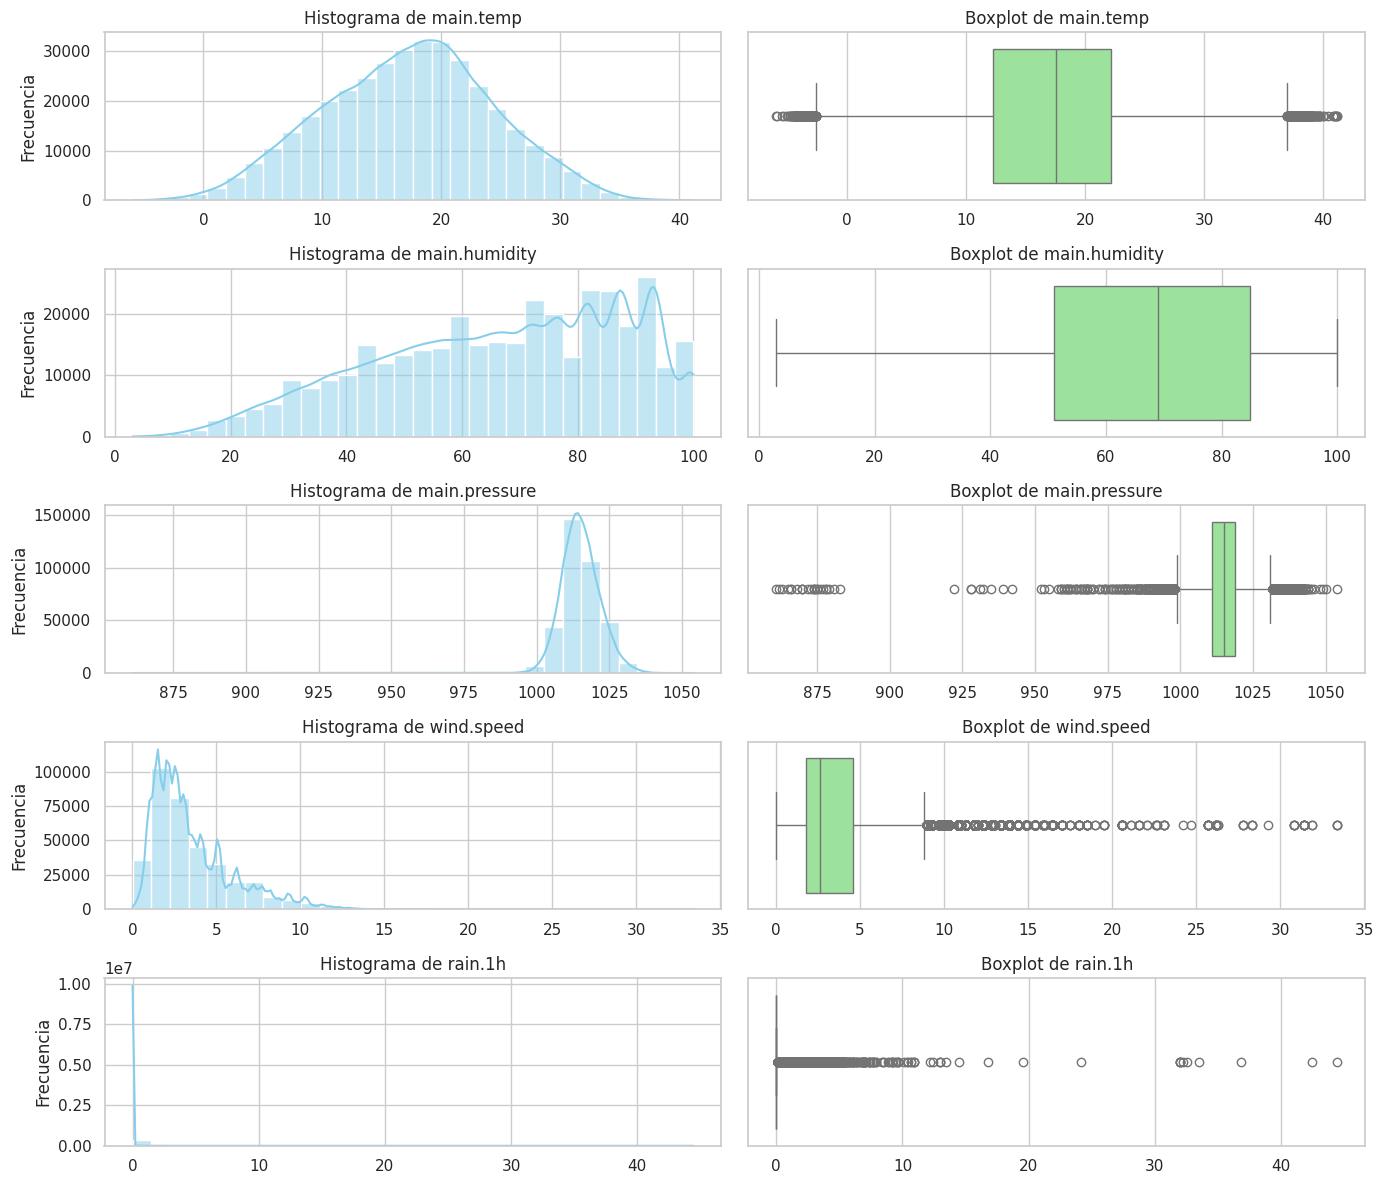

In [ ]:
# B. ANÁLISIS VISUAL (Histogramas y Boxplots)
# Configuramos el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Creamos una grilla de gráficos
fig, axes = plt.subplots(nrows=len(vars_numericas), ncols=2, figsize=(14, 12))

for i, var in enumerate(vars_numericas):
    # Columna Izquierda: Histograma (Vemos la forma de distribución y asimetría)
    sns.histplot(data=df, x=var, kde=True, ax=axes[i, 0], color='skyblue', bins=30)
    axes[i, 0].set_title(f'Histograma de {var}')
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].set_xlabel('')

    # Columna Derecha: Boxplot (Vemos cuartiles y valores atípicos u outliers)
    sns.boxplot(data=df, x=var, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot de {var}')
    axes[i, 1].set_xlabel('')

# Ajustamos los espacios para que no se superpongan los títulos
plt.tight_layout()
plt.show()

##### Variable **objetivo (HELADAS)**

In [ ]:
# A. ANÁLISIS ESTADÍSTICO DESCRIPTIVO
# Calculamos las frecuencias
frec_absoluta = df['helada'].value_counts()
frec_relativa = df['helada'].value_counts(normalize=True) * 100

# Armamos un df
tabla_frecuencias = pd.DataFrame({
    'Frecuencia Absoluta (Horas)': frec_absoluta,
    'Frecuencia Relativa (%)': frec_relativa.round(2).astype(str) + '%'
})
tabla_frecuencias.index = ['0 (Sin Helada)', '1 (Con Helada)']
tabla_frecuencias.index.name = 'Categoría'
display(tabla_frecuencias)

,Frecuencia Absoluta (Horas),Frecuencia Relativa (%)
Categoría,,
0 (Sin Helada),360602,99.52%
1 (Con Helada),1728,0.48%


/tmp/ipykernel_1051/4278915580.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_heladas, x='nombre_mes', order=orden_meses, palette='Blues_r')


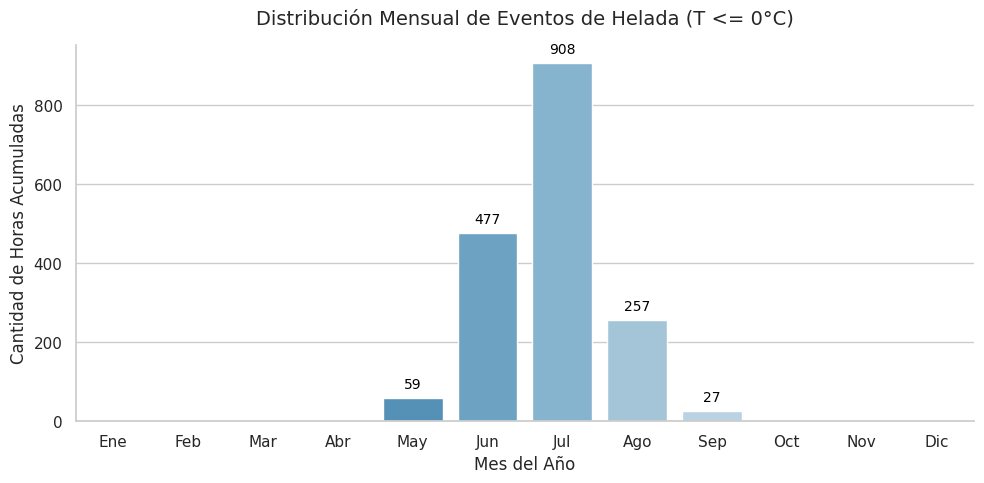

In [ ]:
# B. ANÁLISIS VISUAL
# (Distribución Temporal de las Heladas)

# Filtramos el dataset para quedarnos con las horas donde hubo helada
df_heladas = df[df['helada'] == 1].copy()

# Mapeamos los números de mes a nombres
meses_nombres = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
                 7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
df_heladas['nombre_mes'] = df_heladas['month'].map(meses_nombres)

# Ordenamos los meses cronológicamente para el gráfico
orden_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(10, 5))

# Creamos el gráfico de barras contando las heladas por mes
ax = sns.countplot(data=df_heladas, x='nombre_mes', order=orden_meses, palette='Blues_r')

plt.title('Distribución Mensual de Eventos de Helada (T <= 0°C)', fontsize=14, pad=15)
plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Cantidad de Horas Acumuladas', fontsize=12)

# Agregamos la cantidad exacta arriba de cada barra
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10,
                    color='black', xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

##### Análisis de estacionalidad **(Temperatura vs. Estación del Año)**

In [ ]:
# A. ANÁLISIS ESTADÍSTICO DESCRIPTIVO

# Definimos el orden lógico de las estaciones para tablas y gráficos
orden_estaciones = ['Verano', 'Otoño', 'Invierno', 'Primavera']

print("Estadísticas de Temperatura (°C) agrupadas por Estación:")
# Calculamos media, mediana, min y max agrupando por 'season'
stats_estaciones = df.groupby('season')['main.temp'].agg(
    Media='mean',
    Mediana='median',
    Mínimo='min',
    Máximo='max'
).reindex(orden_estaciones).round(2)

display(stats_estaciones)

Estadísticas de Temperatura (°C) agrupadas por Estación:


,Media,Mediana,Mínimo,Máximo
season,,,,
Verano,22.97,22.44,6.91,41.18
Otoño,17.25,17.18,-3.23,36.40
Invierno,10.91,10.43,-5.95,36.83
Primavera,17.96,17.61,-2.55,40.09


/tmp/ipykernel_1051/3403331351.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='season', y='main.temp', order=orden_estaciones, palette=paleta_clima)


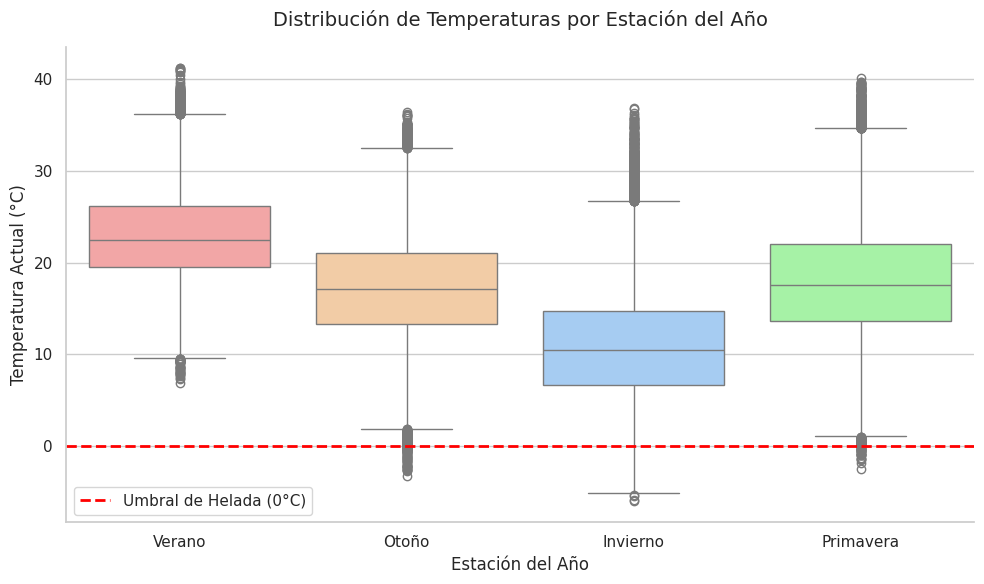

In [ ]:
# B. ANÁLISIS VISUAL
# (Boxplot Agrupado)
plt.figure(figsize=(10, 6))

# Definimos una paleta de colores
paleta_clima = {'Verano': '#ff9999', 'Otoño': '#ffcc99', 'Invierno': '#99ccff', 'Primavera': '#99ff99'}

# Graficamos el boxplot
ax = sns.boxplot(data=df, x='season', y='main.temp', order=orden_estaciones, palette=paleta_clima)

# Agregamos una línea roja en los 0°C (Umbral de Helada)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Umbral de Helada (0°C)')

plt.title('Distribución de Temperaturas por Estación del Año', fontsize=14, pad=15)
plt.xlabel('Estación del Año', fontsize=12)
plt.ylabel('Temperatura Actual (°C)', fontsize=12)
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

##### Análisis Multivariado **(Correlación y Multicolinealidad)**

In [ ]:
# A. ESTADÍSTICA
# Definimos las columnas numéricas que nos interesan y la variable objetivo
cols_corr = ['main.temp', 'main.humidity', 'main.pressure', 'wind.speed', 'rain.1h', 'helada']

# Calculamos la matriz de correlación de Pearson
correlacion = df[cols_corr].corr()

print("Matriz de Correlación de Pearson:")
display(correlacion.round(3))

Matriz de Correlación de Pearson:


,main.temp,main.humidity,main.pressure,wind.speed,rain.1h,helada
main.temp,1.000,-0.338,-0.595,0.324,0.014,-0.181
main.humidity,-0.338,1.000,-0.004,-0.454,0.046,0.039
main.pressure,-0.595,-0.004,1.000,-0.154,-0.023,0.136
wind.speed,0.324,-0.454,-0.154,1.000,-0.004,-0.042
rain.1h,0.014,0.046,-0.023,-0.004,1.000,-0.004
helada,-0.181,0.039,0.136,-0.042,-0.004,1.000


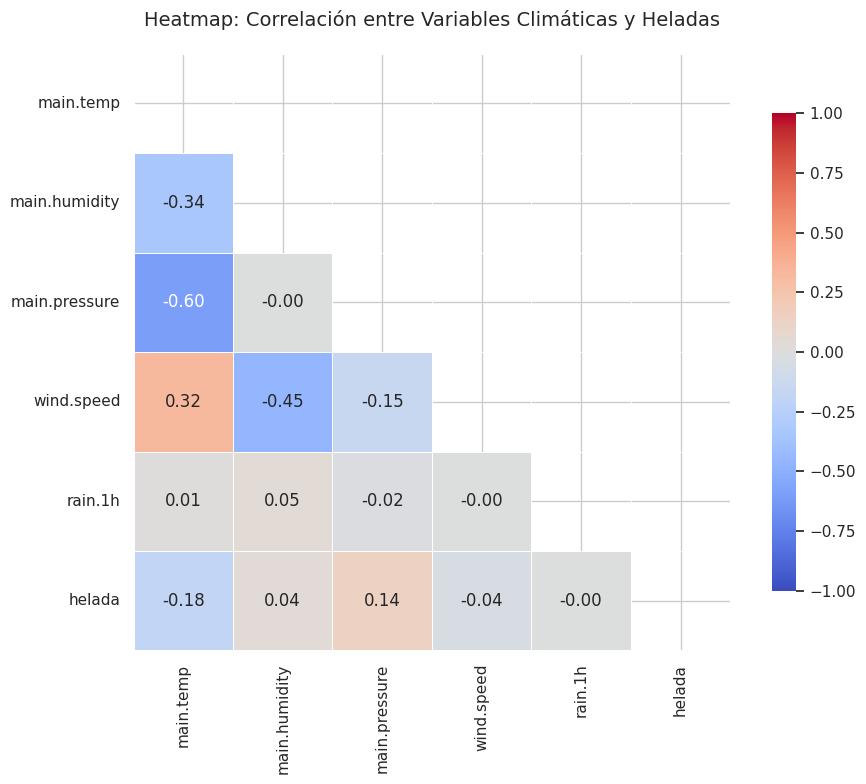

In [ ]:
# B. ANÁLISIS VISUAL
# (Mapa de Calor)
plt.figure(figsize=(10, 8))

# Damos formato triangular
mascara = np.triu(np.ones_like(correlacion, dtype=bool))

# Dibujamos el Heatmap
ax = sns.heatmap(correlacion,
                 mask=mascara,
                 annot=True,          # Muestra los números adentro
                 fmt=".2f",           # Redondea a 2 decimales
                 cmap='coolwarm',     # Colores: Rojo (positivo), Azul (negativo)
                 vmin=-1, vmax=1,     # Rango de la correlación de Pearson
                 center=0,
                 square=True,
                 linewidths=.5,
                 cbar_kws={"shrink": .8})

plt.title('Heatmap: Correlación entre Variables Climáticas y Heladas', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

Al observar la matriz de correlación, resulta contraintuitivo notar que la relación entre la temperatura actual (`main.temp`) y la ocurrencia de heladas (`helada`) arroja un coeficiente de Pearson de apenas **-0.181**, especialmente sabiendo que la helada es un fenómeno dependiente de la temperatura.

Este comportamiento indica dos cosas que tenemos que tener presente en etapas futuras:
1. **Relación No Lineal:** Pearson asume proporcionalidad lineal, pero la helada responde a una función de umbral (Temperatura $\le$ 0°C).
2. **Efecto del Desbalance:** El 99.5% de las horas no registran heladas. Las grandes fluctuaciones de temperatura en esos períodos "normales" diluyen la covarianza matemática, acercando el coeficiente a cero.

**Conclusión para el Modelado (Fase 4):**

 Esta falta de linealidad justifica descartar modelos de regresión simples y optar por **algoritmos basados en árboles (Random Forest, XGBoost)**, los cuales son óptimos para detectar "puntos de corte" (como el 0°C) y lidiar con clases desbalanceadas.

------------------------------------------

##Fase #4: Modelado / Modeling (Ruben / Santi)
En esta fase, se seleccionan y aplican diversas técnicas de modelado y se calibran sus parámetros a valores óptimos. Normalmente, hay varias técnicas para el mismo tipo de problema de minería de datos. Algunas técnicas tienen requisitos específicos en cuanto a la forma de los datos. Por lo tanto, a menudo es necesario volver a la fase de preparación dedatos.
* Seleccioná una variable objetivo que te permita cumplir el objetivo del estudio.
* Investigá un algoritmo de Ciencia de Datos que pueda ayudarte a predecir el comportamiento de esa variable. Explicá brevemente por qué te sería útil.
* Implementa el algoritmo.

### Variable Objetivo

La variable objetivo para este estudio es **`helada`**, una variable binaria que indica la ocurrencia de heladas (1 si la temperatura es $\le$ 0°C, 0 en caso contrario). Esta variable es crucial para cumplir el objetivo del estudio de predecir la ocurrencia de heladas y permitir a los productores tomar medidas preventivas.

### Algoritmo de Ciencia de Datos: Random Forest

Para predecir la variable `helada`, utilizaremos el algoritmo **Random Forest**.

**¿Por qué Random Forest es útil para este problema?**

1.  **Manejo de Relaciones No Lineales:** Como se observó en la fase de exploración de datos, la relación entre la temperatura y la ocurrencia de heladas no es lineal, sino que se basa en un umbral. Random Forest, al ser un ensamblaje de árboles de decisión, es excelente para capturar relaciones complejas y no lineales sin requerir una especificación explícita de la forma funcional.
2.  **Robustez al Desbalance de Clases:** El problema de la predicción de heladas presenta un desbalance de clases significativo (muy pocas horas con helada). Aunque se necesitarán técnicas específicas en la fase de evaluación, Random Forest es inherentemente más robusto a este problema que otros algoritmos lineales.
3.  **Importancia de Características:** Random Forest puede proporcionar una medida de la importancia de cada característica (variable predictora), lo que es valioso para comprender qué factores meteorológicos influyen más en la ocurrencia de heladas.
4.  **Menor Sobreajuste:** Al construir múltiples árboles de decisión y promediar sus predicciones (o realizar una votación mayoritaria para clasificación), Random Forest tiende a reducir el riesgo de sobreajuste en comparación con un solo árbol de decisión.

### Variable Objetivo

La variable objetivo para este estudio es **`helada`**, una variable binaria que indica la ocurrencia de heladas (1 si la temperatura es $\le$ 0°C, 0 en caso contrario). Esta variable es crucial para cumplir el objetivo del estudio de predecir la ocurrencia de heladas y permitir a los productores tomar medidas preventivas.

### Algoritmo de Ciencia de Datos: Random Forest

Para predecir la variable `helada`, utilizaremos el algoritmo **Random Forest**.

**¿Por qué Random Forest es útil para este problema?**

1.  **Manejo de Relaciones No Lineales:** Como se observó en la fase de exploración de datos, la relación entre la temperatura y la ocurrencia de heladas no es lineal, sino que se basa en un umbral. Random Forest, al ser un ensamblaje de árboles de decisión, es excelente para capturar relaciones complejas y no lineales sin requerir una especificación explícita de la forma funcional.
2.  **Robustez al Desbalance de Clases:** El problema de la predicción de heladas presenta un desbalance de clases significativo (muy pocas horas con helada). Aunque se necesitarán técnicas específicas en la fase de evaluación, Random Forest es inherentemente más robusto a este problema que otros algoritmos lineales.
3.  **Importancia de Características:** Random Forest puede proporcionar una medida de la importancia de cada característica (variable predictora), lo que es valioso para comprender qué factores meteorológicos influyen más en la ocurrencia de heladas.
4.  **Menor Sobreajuste:** Al construir múltiples árboles de decisión y promediar sus predicciones (o realizar una votación mayoritaria para clasificación), Random Forest tiende a reducir el riesgo de sobreajuste en comparación con un solo árbol de decisión.

In [ ]:
#Acá debés cargar las librerías con las que trabajarás en esta fase

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#Acá debés poder implementar un modelo y entrenarlo

# Seleccionamos las características (X) y la variable objetivo (y)
# Excluiremos las variables 'dt_iso', 'dt_local', 'year', 'month', 'hour', 'season', 'weather.main', 'weather.description' ya que son temporales, constantes o categóricas que aún no hemos codificado para el modelo.
features = [
    'main.temp',
    'main.feels_like',
    'main.temp_min',
    'main.temp_max',
    'main.pressure',
    'main.humidity',
    'wind.speed',
    'wind.deg',
    'clouds.all',
    'rain.1h'
]

X = df[features]
y = df['helada']

# Dividimos los datos en conjuntos de entrenamiento y prueba
# Usamos stratify=y para mantener la misma proporción de clases en ambos conjuntos, importante por el desbalance.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Proporción de heladas en entrenamiento: {y_train.sum() / len(y_train):.4f}")
print(f"Proporción de heladas en prueba: {y_test.sum() / len(y_test):.4f}")


# Inicializamos y entrenamos el modelo Random Forest
# class_weight='balanced' es crucial para lidiar con el desbalance de clases, asignando mayor peso a la clase minoritaria.
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

print("Modelo Random Forest entrenado exitosamente.")

### Implementación del Algoritmo

In [ ]:
# Seleccionamos las características (X) y la variable objetivo (y)
# Excluiremos las variables 'dt_iso', 'dt_local', 'year', 'month', 'hour', 'season', 'weather.main', 'weather.description' ya que son temporales, constantes o categóricas que aún no hemos codificado para el modelo.
features = [
    'main.temp',
    'main.feels_like',
    'main.temp_min',
    'main.temp_max',
    'main.pressure',
    'main.humidity',
    'wind.speed',
    'wind.deg',
    'clouds.all',
    'rain.1h'
]

X = df[features]
y = df['helada']

# Dividimos los datos en conjuntos de entrenamiento y prueba
# Usamos stratify=y para mantener la misma proporción de clases en ambos conjuntos, importante por el desbalance.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Proporción de heladas en entrenamiento: {y_train.sum() / len(y_train):.4f}")
print(f"Proporción de heladas en prueba: {y_test.sum() / len(y_test):.4f}")

In [ ]:
# Inicializamos y entrenamos el modelo Random Forest
# class_weight='balanced' es crucial para lidiar con el desbalance de clases, asignando mayor peso a la clase minoritaria.
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

print("Modelo Random Forest entrenado exitosamente.")

##Fase #5: Evaluación / Evaluation (Fede / Martina)
En esta etapa del proyecto, ha construido un modelo (o modelos) que parece tener alta calidad desde una perspectiva de análisis de datos. Antes de proceder a la implementación final del modelo, es importante evaluar más a fondo el modelo y revisar los pasos realizados para construir el modelo y asegurarse de que logra correctamente los objetivos comerciales. Un objetivo clave es determinar si hay algún tema importante del negocio que no se hayaconsiderado lo suficiente. Al final de esta fase, se debe tomar una decisión sobre el uso de los resultados de la minería de datos.
* Investigá sobre las métricas que se utilizan para medir el modelo escogido.
* Evalúa dichas métricas en el modelo implementado e intenta explicarlas.

In [ ]:
#Acá debés cargar las librerías con las que trabajarás en esta fase


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
#Acá debés poder validar el modelo, calcular las métricas
#y construir la matriz de confusión


### Evaluación del Modelo

Dado el desbalance de clases (`helada` vs. `no helada`), la métrica de `accuracy` (exactitud) por sí sola puede ser engañosa. Por lo tanto, nos centraremos en métricas que son más adecuadas para problemas con clases desbalanceadas, como `Precision`, `Recall` (Sensibilidad), `F1-Score` y la `Matriz de Confusión`.

In [ ]:
# Realizamos predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

# Calculamos las métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensibilidad): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Mostramos el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

### Explicación de las Métricas

*   **Accuracy (Exactitud)**: Proporción de predicciones correctas sobre el total de predicciones. En problemas desbalanceados, un `accuracy` alto puede ser engañoso si el modelo simplemente predice la clase mayoritaria.

*   **Precision (Precisión)**: De todas las veces que el modelo predijo una helada (clase positiva), ¿cuántas veces realmente hubo una helada? Es crucial cuando el costo de un falso positivo es alto (ej. activar protecciones innecesariamente).

*   **Recall (Sensibilidad o Exhaustividad)**: De todas las heladas que realmente ocurrieron, ¿cuántas fueron detectadas por el modelo? Es vital cuando el costo de un falso negativo es alto (ej. no predecir una helada y perder una cosecha). Para nuestro problema, el `recall` para la clase 'helada' es muy importante.

*   **F1-Score**: Es la media armónica de la precisión y el recall. Es una buena métrica para problemas con clases desbalanceadas, ya que penaliza los modelos con un rendimiento desigual en precisión y recall.

*   **Support**: Es el número de ocurrencias verdaderas de cada clase en `y_test`.

### Matriz de Confusión

La matriz de confusión nos permite visualizar el rendimiento del algoritmo. Muestra las predicciones correctas e incorrectas, desglosadas por clase.

*   **Verdaderos Negativos (TN)**: El modelo predijo 'no helada' y realmente no hubo helada.
*   **Falsos Positivos (FP)**: El modelo predijo 'helada' pero realmente no hubo helada (Error Tipo I).
*   **Falsos Negativos (FN)**: El modelo predijo 'no helada' pero realmente **sí** hubo helada (Error Tipo II). Este es el error más crítico en nuestro contexto.
*   **Verdaderos Positivos (TP)**: El modelo predijo 'helada' y realmente hubo helada.

In [ ]:
# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizamos la matriz de confusión
plt.figure(figsize=(6, 5))
cmd_display = ConfusionMatrixDisplay(cm, display_labels=['No Helada', 'Helada'])
cmd_display.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión')
plt.grid(False) # Remove grid lines as they can obscure the matrix
plt.show()

### Otro Modelo Alternativo: Regresión Logística

La **Regresión Logística** es un algoritmo de clasificación lineal que, a pesar de su nombre, se utiliza para predecir la probabilidad de que una instancia pertenezca a una clase determinada (en este caso, la probabilidad de helada). Aunque Random Forest es más complejo y robusto, la Regresión Logística es útil por varias razones:

1.  **Interpretibilidad:** Es más fácil de interpretar que Random Forest, ya que los coeficientes del modelo pueden indicar la dirección y la fuerza de la relación entre cada característica y la probabilidad de la clase positiva (helada).
2.  **Eficiencia Computacional:** Es generalmente más rápida de entrenar y predecir, lo que la hace adecuada para conjuntos de datos muy grandes o entornos con recursos limitados.
3.  **Buen Punto de Partida:** A menudo se utiliza como un modelo de referencia (baseline) para comparar el rendimiento de algoritmos más complejos.

In [ ]:
from sklearn.linear_model import LogisticRegression

print("Modelo de Regresión Logística cargado.")

In [ ]:
# Inicializamos y entrenamos el modelo de Regresión Logística
# También usamos class_weight='balanced' para manejar el desbalance de clases.
logistic_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
logistic_model.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado exitosamente.")

### Evaluación del Modelo de Regresión Logística

In [ ]:
# Realizamos predicciones sobre el conjunto de prueba con el modelo de Regresión Logística
y_pred_logistic = logistic_model.predict(X_test)

# Calculamos las métricas para Regresión Logística
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print(f"--- Métricas para Regresión Logística ---")
print(f"Accuracy: {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall (Sensibilidad): {recall_logistic:.4f}")
print(f"F1-Score: {f1_logistic:.4f}")

# Mostramos el reporte de clasificación completo para Regresión Logística
print("\nReporte de Clasificación (Regresión Logística):")
print(classification_report(y_test, y_pred_logistic))

In [ ]:
# Calculamos la matriz de confusión para Regresión Logística
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

# Visualizamos la matriz de confusión para Regresión Logística
plt.figure(figsize=(6, 5))
cmd_display_logistic = ConfusionMatrixDisplay(cm_logistic, display_labels=['No Helada', 'Helada'])
cmd_display_logistic.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión (Regresión Logística)')
plt.grid(False)
plt.show()

##Fase #6: Despliegue (Deployment) (Ale Aquino / Victor)
Por lo general, la creación del modelo no es el final del proyecto. Incluso si el propósito delmodelo es aumentar el conocimiento de los datos, el conocimiento adquirido deberá organizarse y presentarse de manera que el cliente pueda utilizarlo. A menudo implica laaplicación de modelos "en vivo" dentro de los procesos de toma de decisiones de una organización, por ejemplo, en la personalización en tiempo real de páginas web o la puntuación repetida de bases de datos de marketing. Sin embargo, en función de los requisitos, la fase de implementación puede ser tan sencilla como generar un informe o tan compleja como implementar un proceso de minería de datos repetible en toda la empresa. En muchos casos, es el cliente, no el analista de datos, quien lleva a cabo los pasos de implementación. Sin embargo, incluso si el analista no llevará a cabo el esfuerzo de implementación, es importante que el cliente comprenda de antemano qué acciones deben llevarse a cabo para hacer uso de los modelos creados.
* Definí un plan para mantener la solución actualizada y funcional. Proporcioná actualizaciones de seguridad y soluciona problemas según sea necesario.
* Colocá acá las vistas del software implementado y el link desde dónde se puede acceder para interactuar con el software (puede estar hardcodeado con las soluciones y gráficos que coloquen acá, en esta notebook).

###Aclaraciones:
* Buscá la síntesis. No nos interesan las largas explicaciones, sino la capacidad de sintetizar el problema.
* No te extiendas más de lo necesario. Utiliza tablas de resumen, herramientas gráficas. Sé creativo. Este no es un trabajo de conocimiento, es un trabajo de aplicación y comunicación de la estrategia.
* No hay respuestas incorrectas, solo problemas de negocio poco explorados 🙂